In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import logging
from glob import glob

# Configuration du logging
logging.basicConfig(
    level=logging.INFO, 
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

def detect_delimiter(file_path, encoding="latin-1"):
    """Détecte le délimiteur en essayant d'abord l'encoding latin-1 (fréquent en France)"""
    delimiters = [";", ",", "\t", "|"]
    
    for sep in delimiters:
        try:
            df_test = pd.read_csv(
                file_path, 
                sep=sep, 
                encoding=encoding, 
                nrows=5, 
                on_bad_lines="skip"
            )
            if df_test.shape[1] > 1:
                return sep
        except Exception:
            continue
    return ";"

def load_and_concat_by_category(input_folder):
    input_path = Path(input_folder)
    if not input_path.exists():
        logger.error(f"Le dossier {input_folder} n'existe pas.")
        return {}

    categories = {
        "usagers": [],
        "vehicules": [],
        "caracteristiques": [],
        "lieux": []
    }
    
    # MISE À JOUR : Ajout de "carct" pour gérer la typo du fichier 2022
    keywords = {
        "usagers": ["usager", "users", "victim"],
        "vehicules": ["vehicule", "vehicle", "veh"],
        "caracteristiques": ["caract", "carct", "features", "accident"], 
        "lieux": ["lieux", "places", "location"]
    }

    csv_files = list(input_path.glob("*.csv"))
    logger.info(f"{len(csv_files)} fichiers CSV trouvés dans {input_folder}")

    if not csv_files:
        return categories

    for file_path in csv_files:
        filename = file_path.name.lower()
        target_category = None
        
        # Identification de la catégorie
        for cat, keys in keywords.items():
            if any(key in filename for key in keys):
                target_category = cat
                break
        
        if not target_category:
            logger.warning(f"Fichier ignoré (catégorie inconnue): {filename}")
            continue

        try:
            logger.info(f"Traitement de {filename}...")
            delimiter = detect_delimiter(file_path)
            
            encoding_used = "utf-8"
            df = pd.read_csv(
                file_path, 
                sep=delimiter, 
                encoding=encoding_used, 
                on_bad_lines="skip",
                low_memory=False
            )
            
            logger.info(f"  -> Encodage utilisé: {encoding_used} | {df.shape[0]} lignes")

            # NETTOYAGE DES ID : Supprime les espaces invisibles dans les colonnes clés
            # Cela évite les problèmes de jointure comme "201 764" vs "201764"
            id_columns = [col for col in df.columns if "Num_Acc" in col or "id_" in col or "num_" in col]
            for col in id_columns:
                if df[col].dtype == 'object':
                    df[col] = df[col].astype(str).str.strip() # Enlève espaces début/fin
                    # Optionnel : si tu veux supprimer TOUS les espaces internes (comme dans ton exemple)
                    # df[col] = df[col].str.replace(" ", "") 

            categories[target_category].append(df)
            
        except Exception as e:
            logger.error(f"Erreur critique lors de la lecture de {filename}: {e}")

    # Concaténation
    final_datasets = {}
    for cat, df_list in categories.items():
        if df_list:
            final_datasets[cat] = pd.concat(df_list, ignore_index=True)
            logger.info(f"✓ {cat.capitalize()} fusionné: {final_datasets[cat].shape[0]} lignes, {final_datasets[cat].shape[1]} colonnes.")
        else:
            logger.warning(f"✗ Aucune donnée pour '{cat}'.")
            final_datasets[cat] = pd.DataFrame()

    return final_datasets

def main():
    input_dir = "../data/raw"
    if not os.path.exists(input_dir):
        logger.error(f"Le dossier {input_dir} n'existe pas.")
        return {}

    logger.info("=== Démarrage du chargement (avec correction encodage & typo) ===")
    datasets = load_and_concat_by_category(input_dir)
    
    logger.info("=== Résumé final ===")
    for name, df in datasets.items():
        if not df.empty:
            print(f"\n--- {name.upper()} ---")
            print(f"Shape: {df.shape}")
            # Affiche les types pour vérifier que les IDs sont bien des strings ou ints propres
            print(f"Types des colonnes:\n{df.dtypes}")
        else:
            print(f"\n--- {name.upper()} --- : Vide")
            
    return datasets

if __name__ == "__main__":
    data = main()
    
    # Vérification rapide d'un ID pour voir si le nettoyage a fonctionné
    if not data['usagers'].empty:
        print("\nAperçu des IDs après nettoyage :")
        print(data['usagers'][['Num_Acc', 'id_vehicule']].head())

2026-08-25 13:47:57,048 - INFO - === Démarrage du chargement (avec correction encodage & typo) ===
2026-08-25 13:47:57,050 - INFO - 16 fichiers CSV trouvés dans ../data/raw
2026-08-25 13:47:57,051 - INFO - Traitement de caract-2023.csv...
2026-08-25 13:47:57,313 - INFO -   -> Encodage utilisé: utf-8 | 54822 lignes
2026-08-25 13:47:57,314 - INFO - Traitement de caract-2024.csv...
2026-08-25 13:47:57,493 - INFO -   -> Encodage utilisé: utf-8 | 54402 lignes
2026-08-25 13:47:57,494 - INFO - Traitement de caracteristiques-2021.csv...
2026-08-25 13:47:57,668 - INFO -   -> Encodage utilisé: utf-8 | 56518 lignes
2026-08-25 13:47:57,669 - INFO - Traitement de carcteristiques-2022.csv...
2026-08-25 13:47:57,860 - INFO -   -> Encodage utilisé: utf-8 | 55302 lignes
2026-08-25 13:47:57,861 - INFO - Traitement de lieux-2021.csv...
2026-08-25 13:47:57,995 - INFO -   -> Encodage utilisé: utf-8 | 56518 lignes
2026-08-25 13:47:57,996 - INFO - Traitement de lieux-2022.csv...
2026-08-25 13:47:58,138 - INF


--- USAGERS ---
Shape: (506791, 16)
Types des colonnes:
Num_Acc          int64
id_vehicule     object
num_veh         object
place            int64
catu             int64
grav             int64
sexe             int64
an_nais        float64
trajet           int64
secu1            int64
secu2            int64
secu3            int64
locp             int64
actp            object
etatp            int64
id_usager       object
dtype: object

--- VEHICULES ---
Shape: (378071, 11)
Types des colonnes:
Num_Acc          int64
id_vehicule     object
num_veh         object
senc             int64
catv             int64
obs              int64
obsm             int64
choc             int64
manv             int64
motor            int64
occutc         float64
dtype: object

--- CARACTERISTIQUES ---
Shape: (221044, 16)
Types des colonnes:
Num_Acc        float64
jour             int64
mois             int64
an               int64
hrmn            object
lum              int64
dep             object
com     

# EDA Technique & Métier 

=== AUDIT DATA QUALITY & MLOPS READINESS ===

--- 1. TAUX DE REMPLISSAGE DES VARIABLES CLÉS ---


C:\Users\vieas\AppData\Local\Temp\ipykernel_22756\1622463404.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="Reds_r")


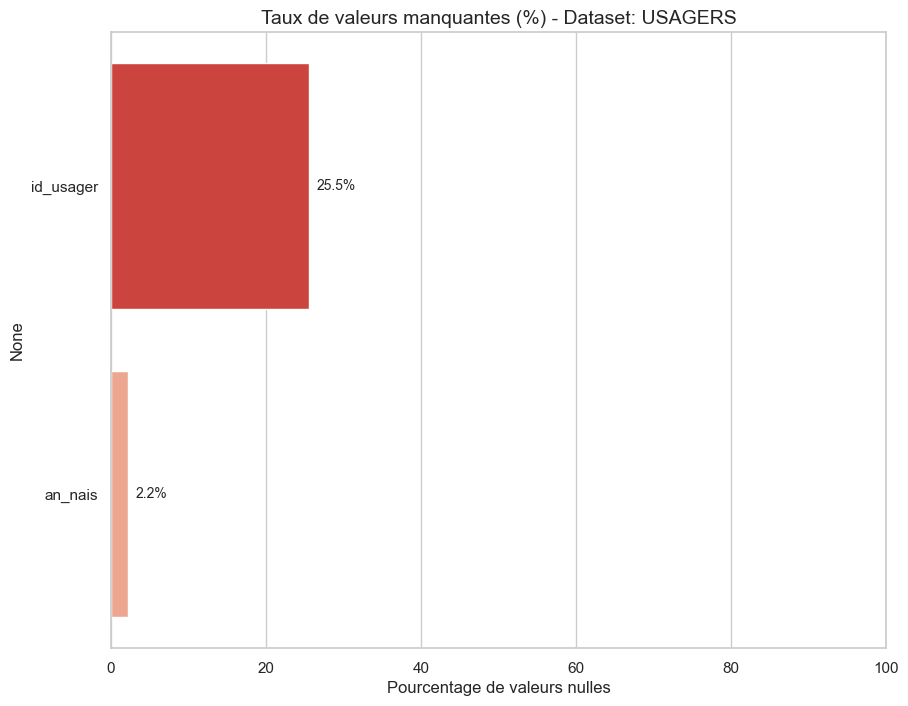

C:\Users\vieas\AppData\Local\Temp\ipykernel_22756\1622463404.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="Reds_r")


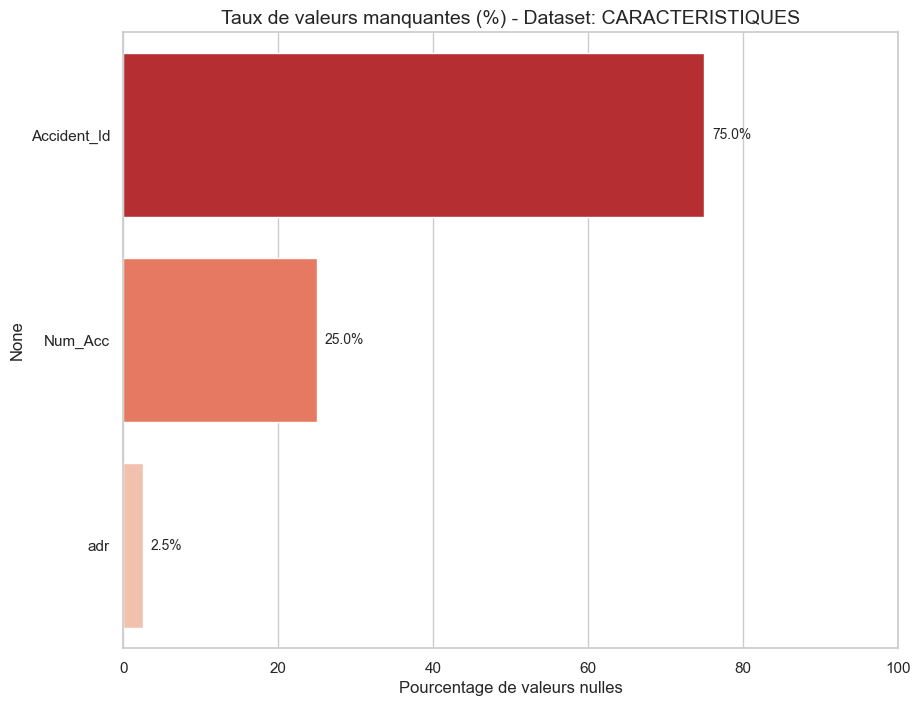

C:\Users\vieas\AppData\Local\Temp\ipykernel_22756\1622463404.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="Reds_r")


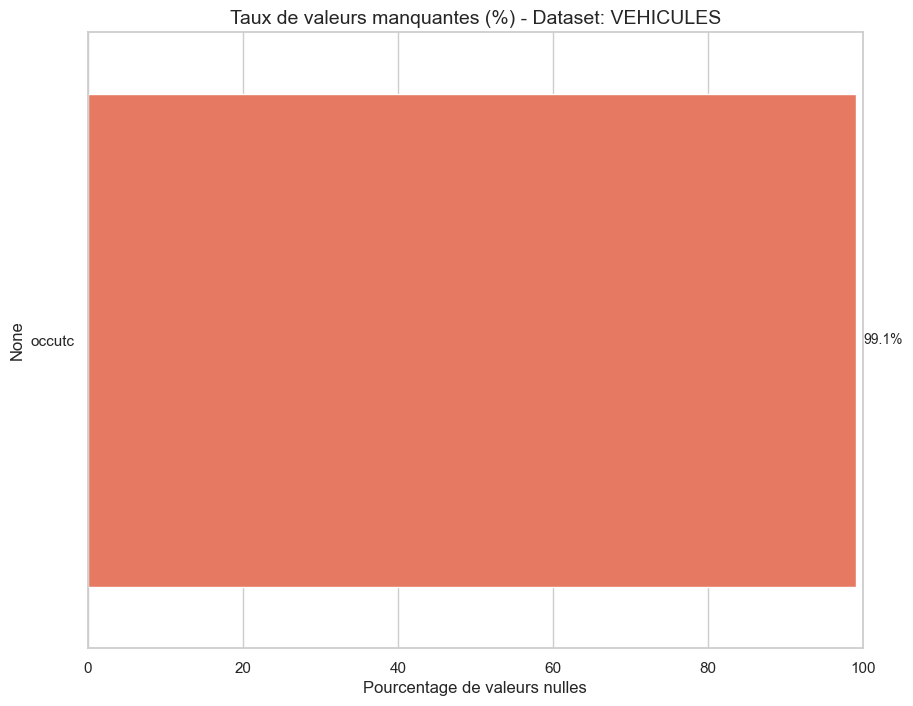

C:\Users\vieas\AppData\Local\Temp\ipykernel_22756\1622463404.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="Reds_r")


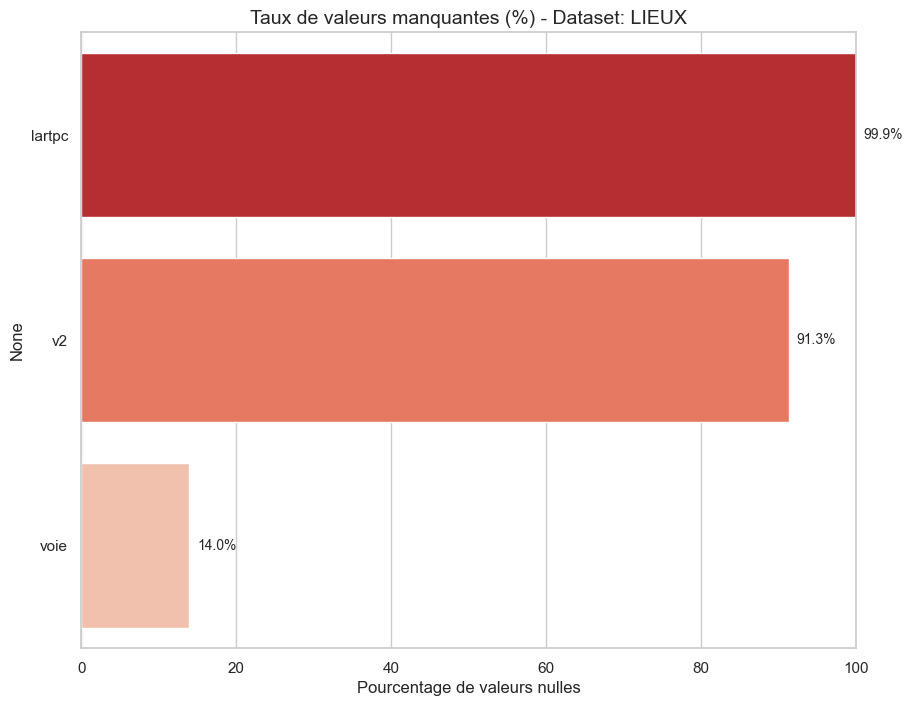


--- 2. ANALYSE DE LA VARIABLE CIBLE (GRAVITÉ) ---


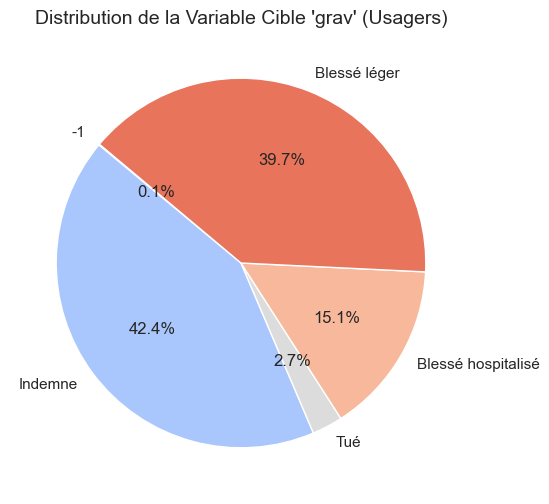

Détail des comptes : 
grav
-1       419
 1    215057
 2     13599
 3     76742
 4    200974
Name: count, dtype: int64
⚠️  ALERT MLOPS : Déséquilibre de classe détecté ! La classe minoritaire représente < 5% des données.
   -> Penser à : Stratified K-Fold, SMOTE, ou pondération des classes (class_weight).

--- 3. DISTRIBUTION DES FEATURES PRINCIPALES ---


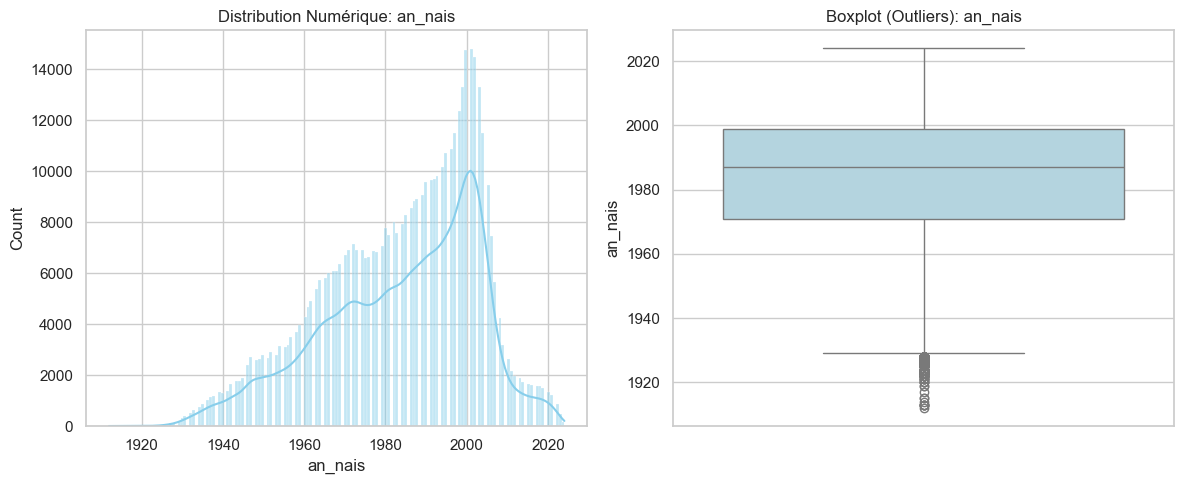

2026-08-25 13:48:07,502 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\vieas\AppData\Local\Temp\ipykernel_22756\1622463404.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette="viridis")
2026-08-25 13:48:07,512 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Note: Vérifier les âges négatifs ou > 120 ans (data cleaning requis).


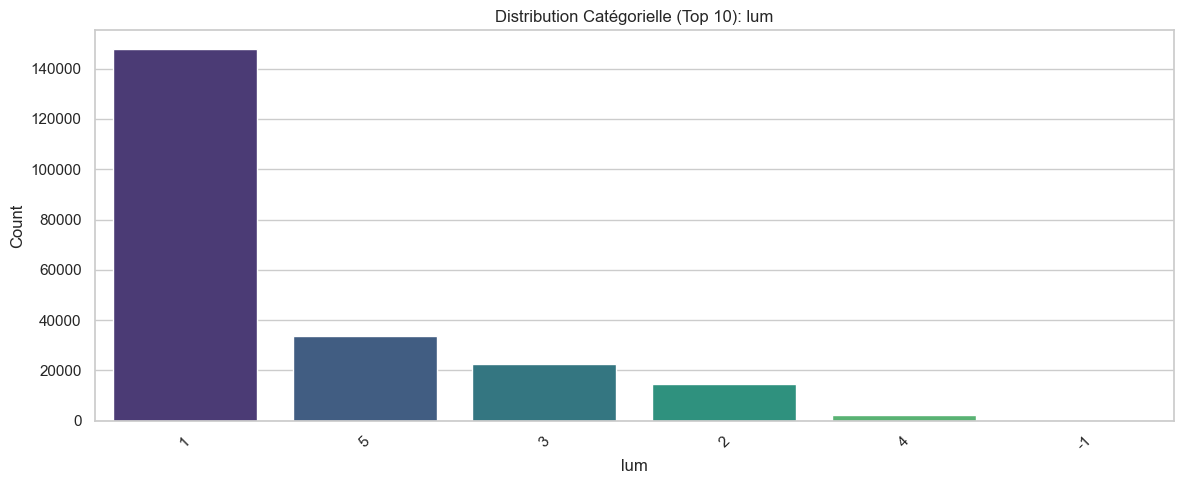

2026-08-25 13:48:07,810 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\vieas\AppData\Local\Temp\ipykernel_22756\1622463404.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, palette="viridis")
2026-08-25 13:48:07,822 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


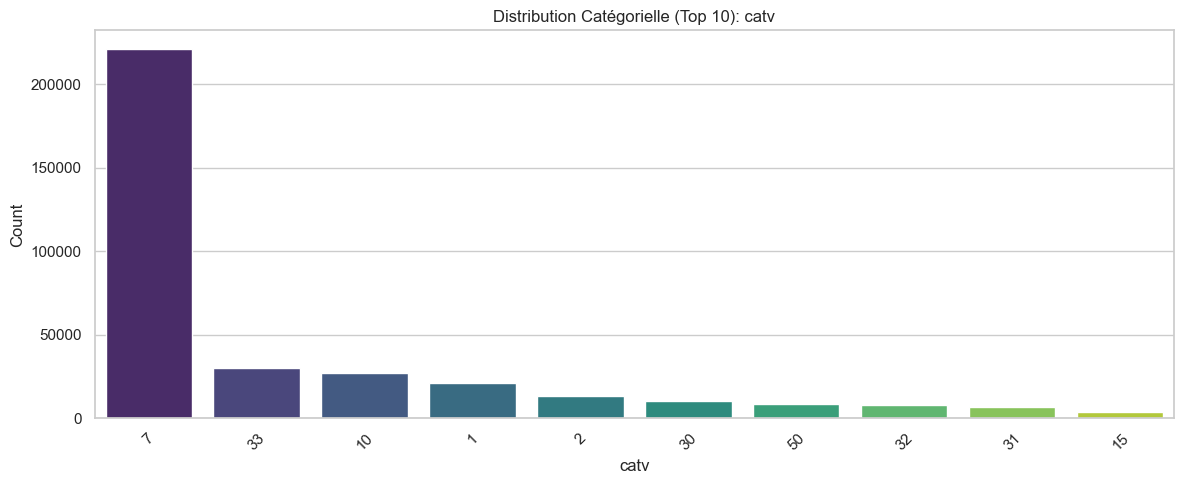


--- 4. CHECKLIST MLOPS & RECOMMANDATIONS ---
Nombre d'accidents uniques (Num_Acc) dans Usagers : 221044
Nombre total de lignes dans Usagers : 506791
⚠️  ATTENTION : Doublons potentiels sur Num_Acc dans le dataset Usagers !
Nombre d'accidents uniques (Num_Acc) dans Véhicules : 221044
Nombre total de lignes dans Véhicules : 378071
⚠️  ATTENTION : Doublons potentiels sur Num_Acc dans le dataset Véhicules !
Nombre d'accidents uniques (Num_Acc) dans Caractéristiques : 165742
Nombre total de lignes dans Caractéristiques : 221044
⚠️  ATTENTION : Doublons potentiels sur Num_Acc dans le dataset Caractéristiques !
Nombre d'accidents uniques (Num_Acc) dans Lieux : 221044
Nombre total de lignes dans Lieux : 252928
⚠️  ATTENTION : Doublons potentiels sur Num_Acc dans le dataset Lieux !


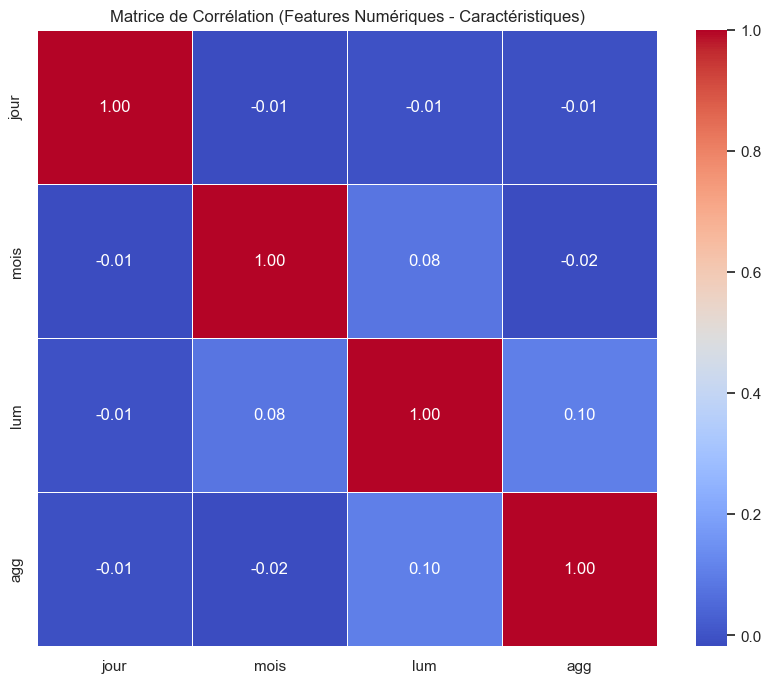

-> Chercher les corrélations fortes (>0.8) qui pourraient indiquer une redondance (multicolinéarité).

=== RÉSUMÉ DES ACTIONS REQUISES AVANT MODELING ===
1. Imputation ou suppression des valeurs NaN (stratégie à définir par colonne).
2. Gestion des outliers (ex: âges > 100 ans, vitesses impossibles).
3. Encodage des variables catégorielles (One-Hot vs Label Encoding).
4. Vérification du Data Drift temporel (les règles ont-elles changé entre 2021 et 2024 ?).
5. Définition de la stratégie de validation croisée (TimeSeriesSplit recommandé ici car données temporelles).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Récupération des données (assumant que 'data' est disponible)
df_usagers = data['usagers']
df_caract = data['caracteristiques']
df_vehicules = data['vehicules']
df_lieux = data['lieux']

print("=== AUDIT DATA QUALITY & MLOPS READINESS ===\n")

# ==============================================================================
# 1. ANALYSE DES VALEURS MANQUANTES (MISSING VALUES)
# ==============================================================================
print("--- 1. TAUX DE REMPLISSAGE DES VARIABLES CLÉS ---")

def plot_missing_percentage(df, name, top_n=15):
    """Calcule et affiche le % de valeurs manquantes par colonne"""
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    # On filtre pour ne garder que les colonnes avec au moins 1% de NaN pour la lisibilité
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False).head(top_n)
    
    if len(missing_pct) == 0:
        print(f"[{name}] Aucune valeur manquante significative.")
        return

    plt.figure(figsize=(10, 8))
    sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="Reds_r")
    plt.title(f"Taux de valeurs manquantes (%) - Dataset: {name}", fontsize=14)
    plt.xlabel("Pourcentage de valeurs nulles")
    plt.xlim(0, 100)
    
    # Annotation des valeurs
    for i, v in enumerate(missing_pct.values):
        plt.text(v + 1, i, f"{v:.1f}%", va='center', fontsize=10)
    
    plt.show()

# Analyse rapide sur les datasets principaux
plot_missing_percentage(df_usagers, "USAGERS")
plot_missing_percentage(df_caract, "CARACTERISTIQUES")
plot_missing_percentage(df_vehicules, "VEHICULES")
plot_missing_percentage(df_lieux, "LIEUX")

# ==============================================================================
# 2. DISTRIBUTION DE LA VARIABLE CIBLE (TARGET)
# ==============================================================================
print("\n--- 2. ANALYSE DE LA VARIABLE CIBLE (GRAVITÉ) ---")
# Pour un problème de classification, on regarde la balance des classes.

if 'grav' in df_usagers.columns:
    target_counts = df_usagers['grav'].value_counts().sort_index()
    
    # Mapping métier pour affichage
    target_map = {1: 'Indemne', 2: 'Tué', 3: 'Blessé hospitalisé', 4: 'Blessé léger'}
    target_labels = [target_map.get(x, str(x)) for x in target_counts.index]
    
    plt.figure(figsize=(8, 6))
    colors = sns.color_palette("coolwarm", len(target_counts))
    plt.pie(target_counts.values, labels=target_labels, autopct='%1.1f%%', startangle=140, colors=colors)
    plt.title("Distribution de la Variable Cible 'grav' (Usagers)", fontsize=14)
    plt.show()
    
    print(f"Détail des comptes : \n{target_counts}")
    
    # Alert MLOps : Déséquilibre de classe ?
    total = len(df_usagers)
    minority_class = target_counts.min()
    if (minority_class / total) < 0.05:
        print("⚠️  ALERT MLOPS : Déséquilibre de classe détecté ! La classe minoritaire représente < 5% des données.")
        print("   -> Penser à : Stratified K-Fold, SMOTE, ou pondération des classes (class_weight).")
else:
    print("Colonne 'grav' non trouvée pour l'analyse de la cible.")

# ==============================================================================
# 3. DISTRIBUTION DES FEATURES (NUMÉRIQUES & CATÉGORIELLES)
# ==============================================================================
print("\n--- 3. DISTRIBUTION DES FEATURES PRINCIPALES ---")

def analyze_feature_distribution(df, col_name, feature_type="num"):
    """Analyse la distribution d'une feature spécifique"""
    if col_name not in df.columns:
        return
    
    data = df[col_name].dropna()
    
    plt.figure(figsize=(12, 5))
    
    if feature_type == "num":
        # Histogramme + KDE pour le numérique
        plt.subplot(1, 2, 1)
        sns.histplot(data, kde=True, color="skyblue")
        plt.title(f"Distribution Numérique: {col_name}")
        plt.xlabel(col_name)
        
        # Boxplot pour détecter les outliers
        plt.subplot(1, 2, 2)
        sns.boxplot(y=data, color="lightblue")
        plt.title(f"Boxplot (Outliers): {col_name}")
        plt.ylabel(col_name)
        
    else:
        # Barplot pour le catégoriel (Top 10)
        counts = data.value_counts().head(10)
        sns.barplot(x=counts.index.astype(str), y=counts.values, palette="viridis")
        plt.title(f"Distribution Catégorielle (Top 10): {col_name}")
        plt.xlabel(col_name)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        
    plt.tight_layout()
    plt.show()

# Exemples de features critiques à analyser selon le métier
# Usagers : âge (calculé), sexe, trajet
# Caractéristiques : lum (lumière), atm (atmosphère), coll (type collision)

# 3.1 Âge des victimes (si an_nais existe)
if 'an_nais' in df_usagers.columns and 'Num_Acc' in df_usagers.columns:
    # Calcul rapide de l'âge approximatif (en supposant que l'année acc est dans Num_Acc ou à part)
    # Ici on fait une approx simple si on a l'année dans une autre colonne, sinon on skip
    # Pour l'exemple, supposons qu'on ait une colonne 'an' dans caractéristiques qu'on pourrait merger, 
    # mais restons simple sur usagers seuls si possible.
    # Si pas d'année事故 claire, on regarde juste la distribution de an_nais
    analyze_feature_distribution(df_usagers, 'an_nais', feature_type="num")
    print("Note: Vérifier les âges négatifs ou > 120 ans (data cleaning requis).")

# 3.2 Conditions lumineuses (Lum) - Catégoriel
if 'lum' in df_caract.columns:
    analyze_feature_distribution(df_caract, 'lum', feature_type="cat")

# 3.3 Catégorie de véhicule (catv) - Catégoriel
if 'catv' in df_vehicules.columns:
    analyze_feature_distribution(df_vehicules, 'catv', feature_type="cat")

# ==============================================================================
# 4. ÉLÉMENTS CRITIQUES MLOPS (DATA DRIFT & CORRELATIONS)
# ==============================================================================
print("\n--- 4. CHECKLIST MLOPS & RECOMMANDATIONS ---")

# 4.1 Vérification des IDs uniques (Pour s'assurer qu'on ne duplique pas des lignes accidentellement)

print(f"Nombre d'accidents uniques (Num_Acc) dans Usagers : {df_usagers['Num_Acc'].nunique()}")
print(f"Nombre total de lignes dans Usagers : {len(df_usagers)}")
if df_usagers['Num_Acc'].nunique() != len(df_usagers):
    print("⚠️  ATTENTION : Doublons potentiels sur Num_Acc dans le dataset Usagers !")

print(f"Nombre d'accidents uniques (Num_Acc) dans Véhicules : {df_vehicules['Num_Acc'].nunique()}")
print(f"Nombre total de lignes dans Véhicules : {len(df_vehicules)}")
if df_vehicules['Num_Acc'].nunique() != len(df_vehicules):
    print("⚠️  ATTENTION : Doublons potentiels sur Num_Acc dans le dataset Véhicules !")

print(f"Nombre d'accidents uniques (Num_Acc) dans Caractéristiques : {df_caract['Num_Acc'].nunique()}")
print(f"Nombre total de lignes dans Caractéristiques : {len(df_caract)}")
if df_caract['Num_Acc'].nunique() != len(df_caract):
    print("⚠️  ATTENTION : Doublons potentiels sur Num_Acc dans le dataset Caractéristiques !")

print(f"Nombre d'accidents uniques (Num_Acc) dans Lieux : {df_lieux['Num_Acc'].nunique()}")
print(f"Nombre total de lignes dans Lieux : {len(df_lieux)}")
if df_lieux['Num_Acc'].nunique() != len(df_lieux):
    print("⚠️  ATTENTION : Doublons potentiels sur Num_Acc dans le dataset Lieux !")

# 4.2 Corrélation rapide (sur les variables numériques de caractéristiques)
numeric_cols = df_caract.select_dtypes(include=[np.number]).columns.tolist()
# On prend quelques cols pertinentes pour ne pas surcharger
cols_to_corr = [c for c in ['jour', 'mois', 'lum', 'dep', 'agg'] if c in numeric_cols]

if len(cols_to_corr) > 1:
    plt.figure(figsize=(10, 8))
    corr_matrix = df_caract[cols_to_corr].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title("Matrice de Corrélation (Features Numériques - Caractéristiques)")
    plt.show()
    print("-> Chercher les corrélations fortes (>0.8) qui pourraient indiquer une redondance (multicolinéarité).")

# 4.3 Résumé des actions de nettoyage requises
print("\n=== RÉSUMÉ DES ACTIONS REQUISES AVANT MODELING ===")
print("1. Imputation ou suppression des valeurs NaN (stratégie à définir par colonne).")
print("2. Gestion des outliers (ex: âges > 100 ans, vitesses impossibles).")
print("3. Encodage des variables catégorielles (One-Hot vs Label Encoding).")
print("4. Vérification du Data Drift temporel (les règles ont-elles changé entre 2021 et 2024 ?).")
print("5. Définition de la stratégie de validation croisée (TimeSeriesSplit recommandé ici car données temporelles).")

# EDA (Exploratory Data Analysis)

2026-08-25 13:48:08,386 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\vieas\AppData\Local\Temp\ipykernel_22756\637404216.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accidents_par_an.index, y=accidents_par_an.values, palette="viridis")
2026-08-25 13:48:08,407 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


=== LANCEMENT DE L'EDA ===


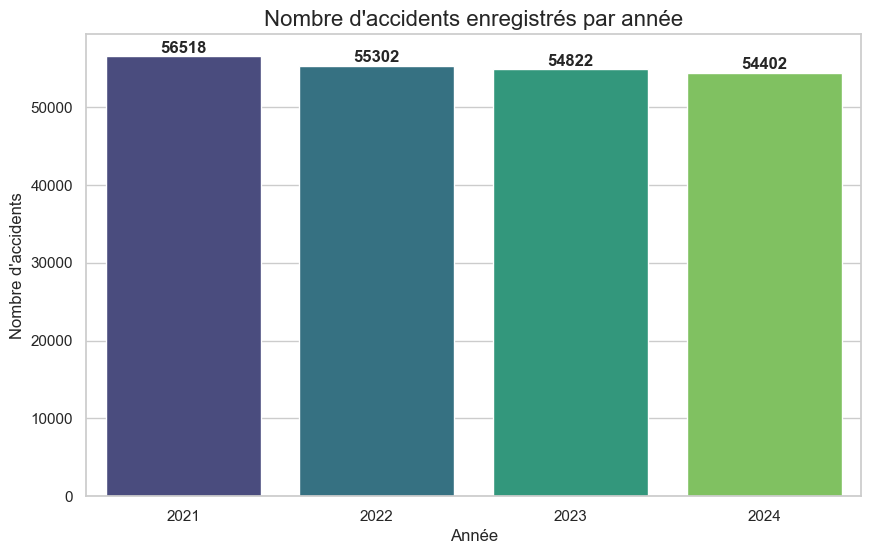

C:\Users\vieas\AppData\Local\Temp\ipykernel_22756\637404216.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grav_counts.index, y=grav_counts.values, palette="coolwarm")


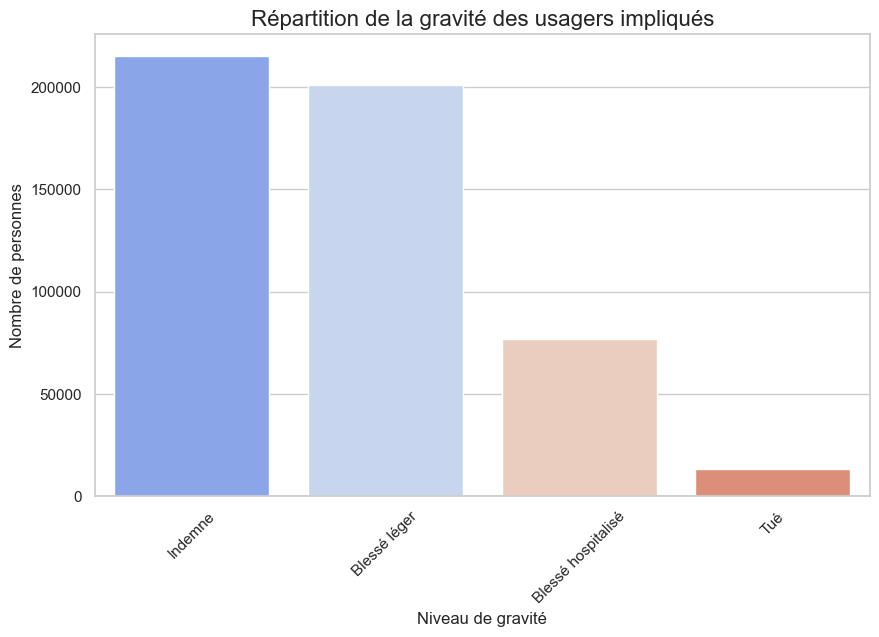

2026-08-25 13:48:08,883 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\vieas\AppData\Local\Temp\ipykernel_22756\637404216.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=veh_counts.index, y=veh_counts.values, palette="magma")
2026-08-25 13:48:08,894 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


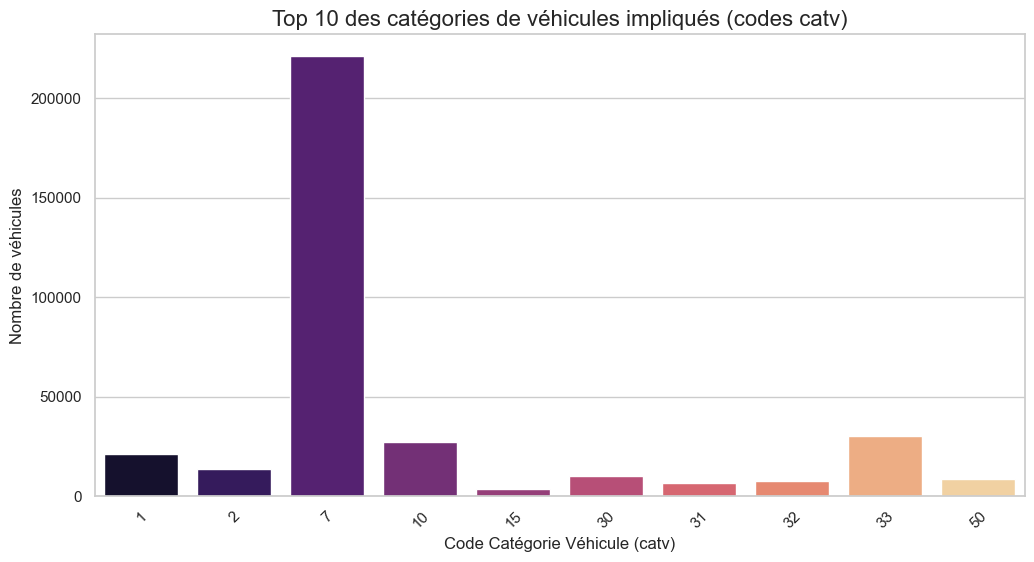

=== FIN DES GRAPHIQUES ===


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style pour de beaux graphiques
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# On suppose que la variable 'data' contient tes 4 dataframes retournés par main()
df_usagers = data['usagers']
df_caract = data['caracteristiques']
df_vehicules = data['vehicules']
df_lieux = data['lieux']

print("=== LANCEMENT DE L'EDA ===")

# ---------------------------------------------------------
# GRAPHIQUE 1 : Évolution du nombre d'accidents par année
# Source : dataset 'caracteristiques'
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# On compte le nombre d'accidents par année
accidents_par_an = df_caract['an'].value_counts().sort_index()

sns.barplot(x=accidents_par_an.index, y=accidents_par_an.values, palette="viridis")
plt.title("Nombre d'accidents enregistrés par année", fontsize=16)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'accidents", fontsize=12)
plt.xticks(rotation=0)
# Ajout des valeurs au-dessus des barres
for i, v in enumerate(accidents_par_an.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.show()

# ---------------------------------------------------------
# GRAPHIQUE 2 : Répartition de la gravité des usagers
# Source : dataset 'usagers'
# Variable 'grav' : 1=indemne, 2=blessé léger, 3=blessé hospitalisé, 4=décédé
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# On remplace les codes par des labels pour la lisibilité (optionnel mais mieux)
label_grav = {1: 'Indemne', 2: 'Tué', 3: 'Blessé hospitalisé', 4: 'Blessé léger'}
df_usagers['grav_label'] = df_usagers['grav'].map(label_grav)

# Compte des valeurs
grav_counts = df_usagers['grav_label'].value_counts()

# On filtre pour enlever les NaN s'il y en a
grav_counts = grav_counts.dropna()

sns.barplot(x=grav_counts.index, y=grav_counts.values, palette="coolwarm")
plt.title("Répartition de la gravité des usagers impliqués", fontsize=16)
plt.xlabel("Niveau de gravité", fontsize=12)
plt.ylabel("Nombre de personnes", fontsize=12)
plt.xticks(rotation=45)
plt.show()

# ---------------------------------------------------------
# GRAPHIQUE 3 : Type de véhicules impliqués (Top 10)
# Source : dataset 'vehicules'
# Variable 'catv' : Catégorie du véhicule (code numérique)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
# On compte les véhicules par catégorie
veh_counts = df_vehicules['catv'].value_counts().head(10) # Top 10 des catégories

sns.barplot(x=veh_counts.index, y=veh_counts.values, palette="magma")
plt.title("Top 10 des catégories de véhicules impliqués (codes catv)", fontsize=16)
plt.xlabel("Code Catégorie Véhicule (catv)", fontsize=12)
plt.ylabel("Nombre de véhicules", fontsize=12)
plt.xticks(rotation=45)
plt.show()

print("=== FIN DES GRAPHIQUES ===")